[(',', 336), ('’', 267), (':', 106), ('‘', 84), ('album', 55), ('—', 46), ('(', 33), (')', 33), (';', 28), ('record', 27), ('artist', 24), ('company', 24), ('reviewed', 23), ('like', 22), ('?', 21), ('band', 19), ('one', 18), ('.', 15), ('rock', 14), ('country', 12), ('new', 12), ('sound', 11), ('good', 11), ('get', 11), ('songs', 11), ('!', 10), ('made', 10), ('many', 10), ('much', 10), ("'", 10), ('something', 10), ('album.', 10), ('guitar', 9), ('vocals', 9), ('back', 9), ('well', 9), ('know', 8), ('could', 8), ('song', 8), ('pop', 8), ('n', 8), ('would', 7), ('even', 7), ('tracks', 7), ('time', 7), ('another', 7), ('sounds', 7), ('sweet', 7), ('stone', 7), ('american', 7), ('...', 7), ('misfits', 7), ('full', 6), ('great', 6), ('love', 6), ('way', 6), ('make', 6), ('harper', 6), ('live', 6), ('fact', 6), ('without', 6), ('last', 6), ('charlatans', 6), ('troy', 6), ('ferguson', 6), ('music', 6), ('sense', 6), ('squire', 6), ('roses', 6), ('track', 6), ('albums', 5), ('space', 5), ('

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


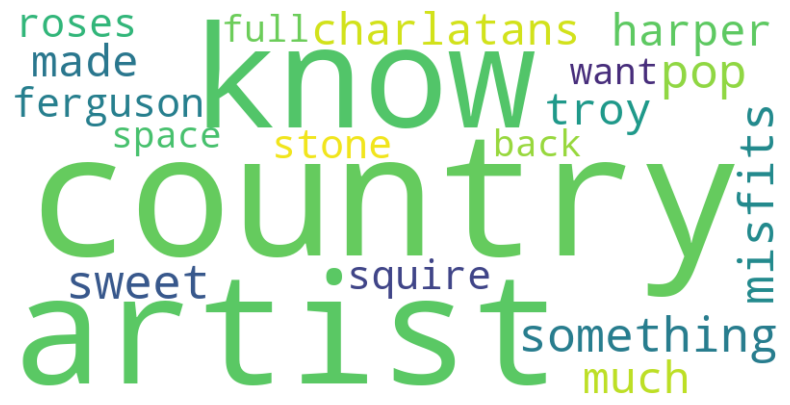

[('music', 14), ('one', 13), ('group', 13), ('side', 12), ('billy', 12), ('vocal', 12), ('love', 11), ('miracles', 11), ('first', 10), ('gong', 10), ('disco', 10), ('paul', 10), ('seasons', 10), ('left', 9), ('still', 9), ('good', 9), ('four', 9), ('little', 9), ('lyrics', 8), ('soul', 8)]


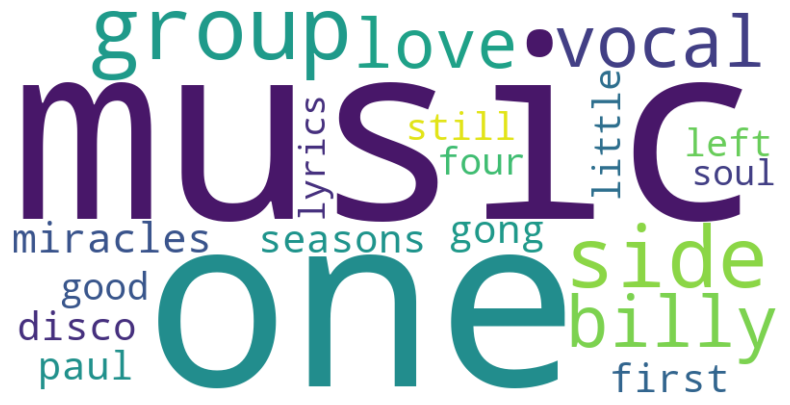

<class 'nltk.probability.FreqDist'>


In [ ]:
import nltk
import string
from nltk.corpus import PlaintextCorpusReader
from nltk import FreqDist
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt


nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Or use NLTK's PlaintextCorpusReader for a directory of text files
corpus_root = '.'  # Directory containing your text files
file_pattern = r'.*\.txt'  # Pattern to match .txt files
corpus = PlaintextCorpusReader(corpus_root, file_pattern)

# Access the text
words = corpus.words('ALBUMS 97.06.01.txt')
raw_text_97 = corpus.raw('ALBUMS 97.06.01.txt')

# print(type(corpus))
# print(type(words))
tokens = nltk.word_tokenize(raw_text_97.lower(), language='english', preserve_line=True)
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
punctuation_set = set(string.punctuation)
punctuation_set.update(["'s", "'", '"', '’', '“', '”', '–', '—', '...', '``', "''", '‘', '•'])
reserved_words = set(["reviewed", "album", "record", "company","artist"])
filtered_tokens_2 = [word for word in filtered_tokens if word not in punctuation_set and word not in reserved_words]
concordance_1 = FreqDist(filtered_tokens_2)

# print(type(tokens))
# text = nltk.Text(filtered_tokens)
# print(text.concordance('rock'))
print(FreqDist(filtered_tokens).most_common(100))
print(FreqDist(filtered_tokens_2).most_common(100))

raw_text_77 = corpus.raw('RECORDS 77.06.01.txt')

# print(type(corpus))
# print(type(words))
tokens = nltk.word_tokenize(raw_text_77.lower(), language='english', preserve_line=True)
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
filtered_tokens_2 = [word for word in filtered_tokens if word not in punctuation_set and word not in reserved_words]
# print(type(tokens))
# text = nltk.Text(filtered_tokens)
# print(text.concordance('disco'))
concordance_2 = FreqDist(filtered_tokens_2)
print(FreqDist(filtered_tokens).most_common(100))
print(FreqDist(filtered_tokens_2).most_common(100))

more_in_1 = concordance_1 - concordance_2  # Words more common in first corpus
more_in_2 = concordance_2 - concordance_1  # Words more common in second corpus
print(more_in_1.most_common(20))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(more_in_1.most_common(20)))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Turn off the axis labels
plt.show()
print(more_in_2.most_common(20))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(more_in_2.most_common(20)))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Turn off the axis labels
plt.show()
print(type(concordance_1))